In [1]:
import numpy as np
import pandas as pd

In [2]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [4]:
df=pd.read_csv('Titanic-Dataset.csv',usecols=['Age','Fare','Survived'])

In [5]:
df.sample(5)

,Survived,Age,Fare
852,0,9.0,15.2458
583,0,36.0,40.1250
57,0,28.5,7.2292
117,0,29.0,21.0000
119,0,2.0,31.2750


In [6]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [12]:
df['Age'].fillna(df['Age'].mean(),inplace=True)

/tmp/ipykernel_14479/694922604.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)


In [13]:
df.sample(5)

,Survived,Age,Fare
748,0,19.000000,53.1000
602,0,29.699118,42.4000
444,1,29.699118,8.1125
850,0,4.000000,31.2750
799,0,30.000000,24.1500


In [14]:
x=df.iloc[:,1:3]
y=df.iloc[:,0]

In [15]:
x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42)

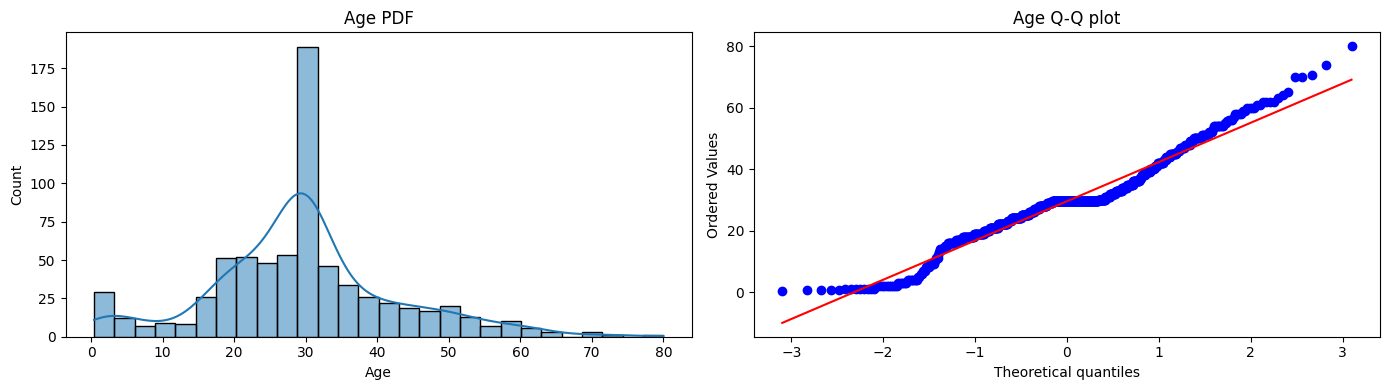

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))


sns.histplot(x_train['Age'], kde=True, ax=axes[0])
axes[0].set_title("Age PDF")


stats.probplot(x_train['Age'], dist='norm', plot=axes[1])
axes[1].set_title("Age Q-Q plot")

plt.tight_layout()
plt.show()

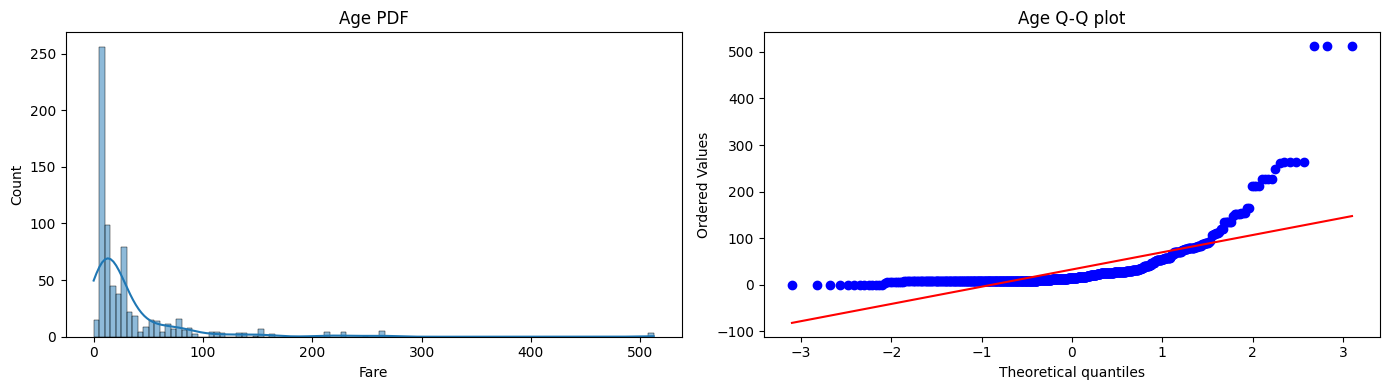

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))


sns.histplot(x_train['Fare'], kde=True, ax=axes[0])
axes[0].set_title("Age PDF")


stats.probplot(x_train['Fare'], dist='norm', plot=axes[1])
axes[1].set_title("Age Q-Q plot")

plt.tight_layout()
plt.show()

In [30]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()

In [32]:
clf.fit(x_train,y_train)
clf2.fit(x_train,y_train)
y_pred=clf.predict(x_test)
y_pred2=clf2.predict(x_test)
print('Accuracy Logistic Regression:',accuracy_score(y_test,y_pred))
print('Accuracy Decision Tree:',accuracy_score(y_test,y_pred2))

Accuracy Logistic Regression: 0.6480446927374302
Accuracy Decision Tree: 0.6927374301675978


In [33]:
trf=FunctionTransformer(func=np.log1p)

In [34]:
x_train_transformed=trf.fit_transform(x_train)
x_test_transformed=trf.transform(x_test)

In [35]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()
clf.fit(x_train_transformed,y_train)
clf2.fit(x_train_transformed,y_train)
y_pred=clf.predict(x_test_transformed)
y_pred2=clf2.predict(x_test_transformed)
print('Accuracy Logistic Regression:',accuracy_score(y_test,y_pred))
print('Accuracy Decision Tree:',accuracy_score(y_test,y_pred2))

Accuracy Logistic Regression: 0.6815642458100558
Accuracy Decision Tree: 0.6759776536312849


In [36]:
x_transformed=trf.fit_transform(x)
clf=LogisticRegression()
clf2=DecisionTreeClassifier()
print('Logistic Regression:',np.mean(cross_val_score(
                      clf,x_transformed,y,scoring='accuracy',cv=10               
																		 )))

print('Decision Tree:',np.mean(cross_val_score(
                      clf2,x_transformed,y,scoring='accuracy',cv=10               
																		 )))

Logistic Regression: 0.678027465667915
Decision Tree: 0.6622097378277153


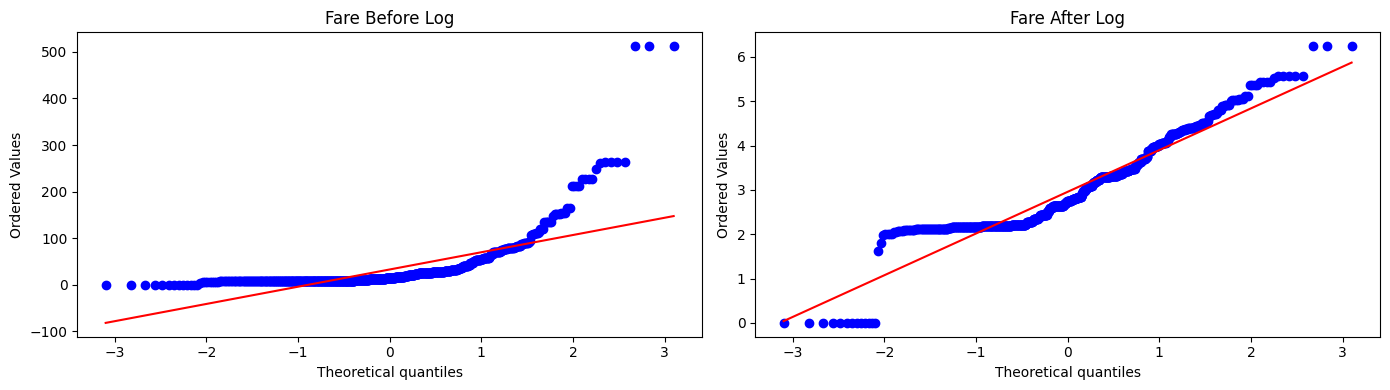

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))


stats.probplot(x_train['Fare'], dist='norm', plot=axes[0])
axes[0].set_title("Fare Before Log")


stats.probplot(x_train_transformed['Fare'], dist='norm', plot=axes[1])
axes[1].set_title("Fare After Log")

plt.tight_layout()
plt.show()

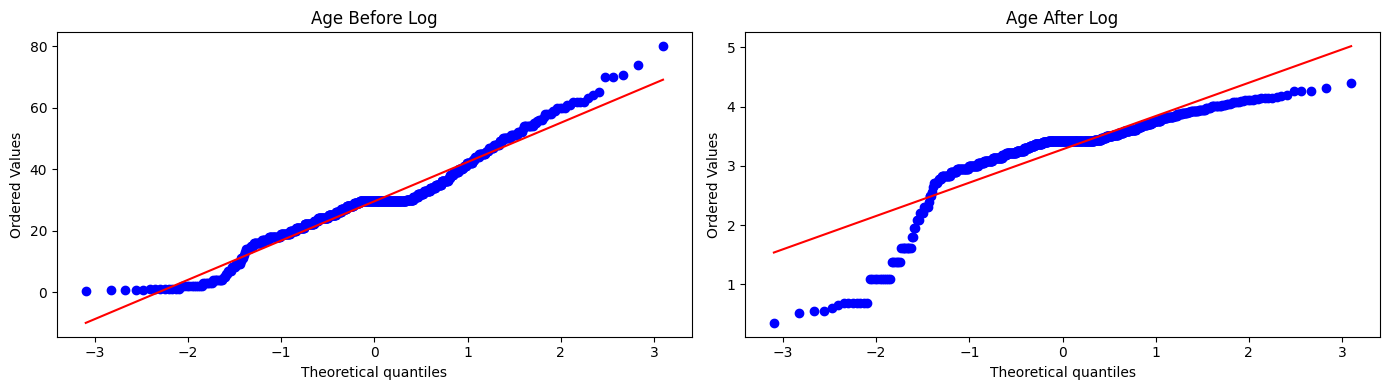

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))


stats.probplot(x_train['Age'], dist='norm', plot=axes[0])
axes[0].set_title("Age Before Log")


stats.probplot(x_train_transformed['Age'], dist='norm', plot=axes[1])
axes[1].set_title("Age After Log")

plt.tight_layout()
plt.show()

In [43]:
trf2=ColumnTransformer([(
    'log',FunctionTransformer(func=np.log1p),['Fare']
)],remainder='passthrough')

x_train_transformed2=trf2.fit_transform(x_train)
x_test_transformed2=trf2.transform(x_test)

In [44]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()
clf.fit(x_train_transformed2,y_train)
clf2.fit(x_train_transformed2,y_train)
y_pred=clf.predict(x_test_transformed2)
y_pred2=clf2.predict(x_test_transformed2)
print('Accuracy Logistic Regression:',accuracy_score(y_test,y_pred))
print('Accuracy Decision Tree:',accuracy_score(y_test,y_pred2))

Accuracy Logistic Regression: 0.6703910614525139
Accuracy Decision Tree: 0.6703910614525139


In [46]:
x_transformed2 = trf2.fit_transform(x)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,x_transformed2,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,x_transformed2,y,scoring='accuracy',cv=10)))

LR 0.6712609238451936
DT 0.6588514357053683


In [47]:
def apply_transform(transform):
    X = df.iloc[:,1:3]
    y = df.iloc[:,0]
    
    trf = ColumnTransformer([('log',FunctionTransformer(transform),['Fare'])],remainder='passthrough')
    
    X_trans = trf.fit_transform(X)
    
    clf = LogisticRegression()
    
    print("Accuracy",np.mean(cross_val_score(clf,X_trans,y,scoring='accuracy',cv=10)))
    
    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X['Fare'], dist="norm", plot=plt)
    plt.title('Fare Before Transform')

    plt.subplot(122)
    stats.probplot(X_trans[:,0], dist="norm", plot=plt)
    plt.title('Fare After Transform')

    plt.show()

Accuracy 0.6195131086142323


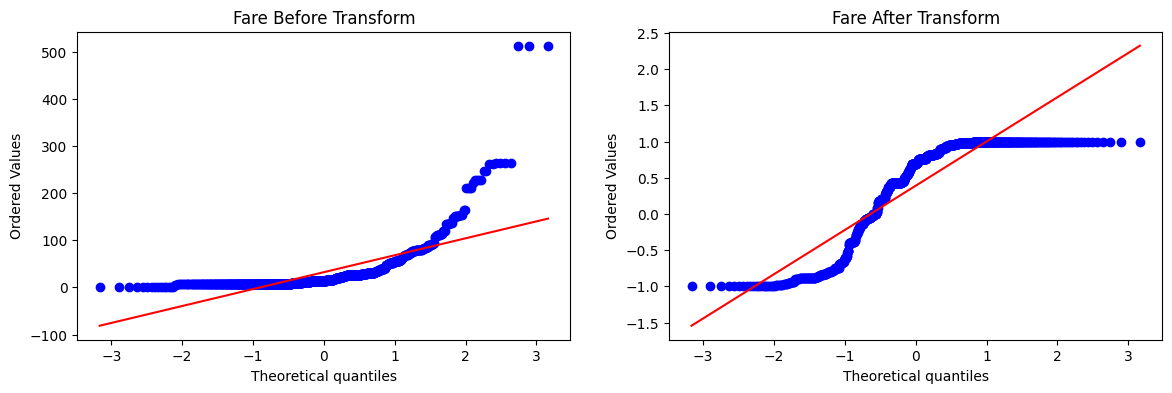

In [48]:
apply_transform(np.sin)